# Bioreactor Unit Operations

This notebook demonstrates the bioreactor models in difflow_bio:
- **ContinuousBioreactor (Chemostat)**: Steady-state continuous culture
- **FedBatchBioreactor**: Fed-batch cultivation with substrate feeding

Both models support:
- Monod and other growth kinetics
- Product formation (growth-associated and non-growth-associated)
- Full automatic differentiation for optimization

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow_bio import (
    ContinuousBioreactor,
    FedBatchBioreactor,
    BioreactorParams,
    FedBatchParams,
    monod_kinetics,
)
from difflow import make_stream, get_flows

## 1. Continuous Bioreactor (Chemostat)

A chemostat operates at steady state with continuous feed and harvest.
Key equations:
- Cell balance: $0 = D(X_{in} - X) + (\mu - k_d)X$
- Substrate balance: $0 = D(S_f - S) - \mu X/Y_{xs} - m_s X$
- Product balance: $0 = D(P_{in} - P) + (\alpha\mu + \beta)X$

In [2]:
# Define chemostat parameters
params = BioreactorParams(
    V=10.0,                    # 10 L reactor volume
    Y_xs=0.5,                  # 0.5 g cells / g substrate
    kinetic_fn=monod_kinetics,
    kinetic_params={
        "mu_max": jnp.array(0.4),  # 0.4 h^-1 max growth rate
        "K_s": jnp.array(0.5),     # 0.5 g/L half-saturation
    },
    k_d=0.02,                  # Death rate
    alpha=0.1,                 # Growth-associated product
    beta=0.01,                 # Non-growth-associated product
)

chemostat = ContinuousBioreactor(params)

# Create sterile feed (glucose in water)
# At D=0.2 h^-1, F=2 L/h, feed substrate = 20 g/L -> 40 g/h
feed = make_stream(
    {"cells": 0.0, "substrate": 40.0, "product": 0.0},
    T=310.0,
    P=101325.0
)

# Run at D = 0.2 h^-1
outlet, info = chemostat(feed, D=0.2)

print("Chemostat Steady State:")
print(f"  Cell concentration: {float(info['X']):.2f} g/L")
print(f"  Residual substrate: {float(info['S']):.2f} g/L")
print(f"  Product concentration: {float(info['P']):.3f} g/L")
print(f"  Growth rate mu: {float(info['mu']):.3f} h^-1")
print(f"  Cell productivity: {float(info['cell_productivity']):.2f} g/L/h")

Chemostat Steady State:
  Cell concentration: 8.81 g/L
  Residual substrate: 0.61 g/L
  Product concentration: 1.410 g/L
  Growth rate mu: 0.220 h^-1
  Cell productivity: 1.76 g/L/h


### Effect of Dilution Rate

Let's explore how dilution rate affects cell concentration and productivity.

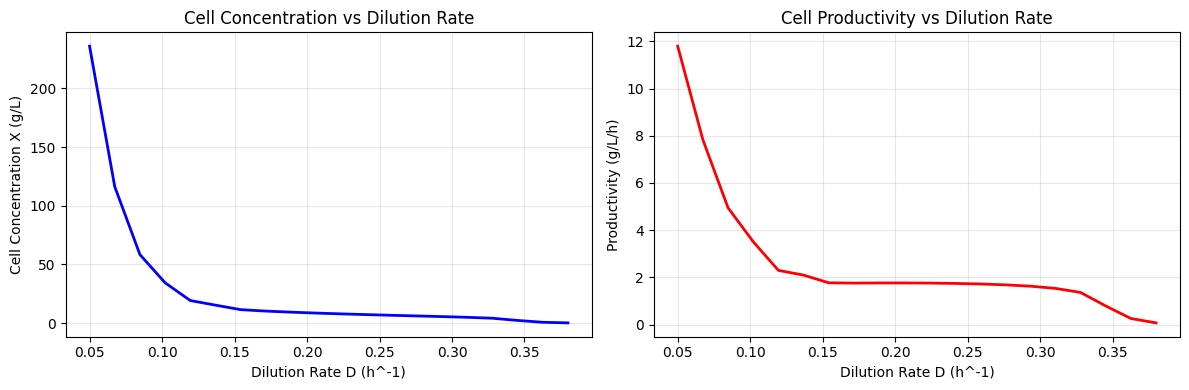


Optimal D for max productivity: 0.050 h^-1
Maximum productivity: 11.801 g/L/h


In [3]:
# Scan dilution rates
D_values = jnp.linspace(0.05, 0.38, 20)
X_values = []
productivity_values = []

for D in D_values:
    _, info = chemostat(feed, D=float(D))
    X_values.append(float(info['X']))
    productivity_values.append(float(info['cell_productivity']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(D_values, X_values, 'b-', linewidth=2)
ax1.set_xlabel('Dilution Rate D (h^-1)')
ax1.set_ylabel('Cell Concentration X (g/L)')
ax1.set_title('Cell Concentration vs Dilution Rate')
ax1.grid(True, alpha=0.3)

ax2.plot(D_values, productivity_values, 'r-', linewidth=2)
ax2.set_xlabel('Dilution Rate D (h^-1)')
ax2.set_ylabel('Productivity (g/L/h)')
ax2.set_title('Cell Productivity vs Dilution Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal D
max_idx = jnp.argmax(jnp.array(productivity_values))
print(f"\nOptimal D for max productivity: {D_values[max_idx]:.3f} h^-1")
print(f"Maximum productivity: {productivity_values[max_idx]:.3f} g/L/h")

### Gradient-Based Optimization

Since the model is differentiable, we can use gradient descent to find the optimal dilution rate.

In [4]:
def cell_productivity(D):
    """Compute cell productivity as function of D."""
    _, info = chemostat(feed, D=D)
    return -info['cell_productivity']  # Negative for minimization

# Compute gradient
grad_fn = jax.grad(cell_productivity)

# Simple gradient descent
D = jnp.array(0.1)
lr = 0.5

print("Gradient Descent Optimization:")
for i in range(20):
    g = grad_fn(D)
    D = D - lr * g
    D = jnp.clip(D, 0.05, 0.38)  # Keep in valid range
    if i % 5 == 0:
        prod = -cell_productivity(D)
        print(f"  Iter {i}: D = {float(D):.4f}, productivity = {float(prod):.4f}")

print(f"\nOptimal D from gradient descent: {float(D):.4f} h^-1")

Gradient Descent Optimization:
  Iter 0: D = 0.0500, productivity = 11.8009
  Iter 5: D = 0.0500, productivity = 11.8009
  Iter 10: D = 0.0500, productivity = 11.8009
  Iter 15: D = 0.0500, productivity = 11.8009

Optimal D from gradient descent: 0.0500 h^-1


## 2. Fed-Batch Bioreactor

Fed-batch operation starts as a batch and feeds substrate to maintain growth while avoiding substrate inhibition or overflow metabolism.

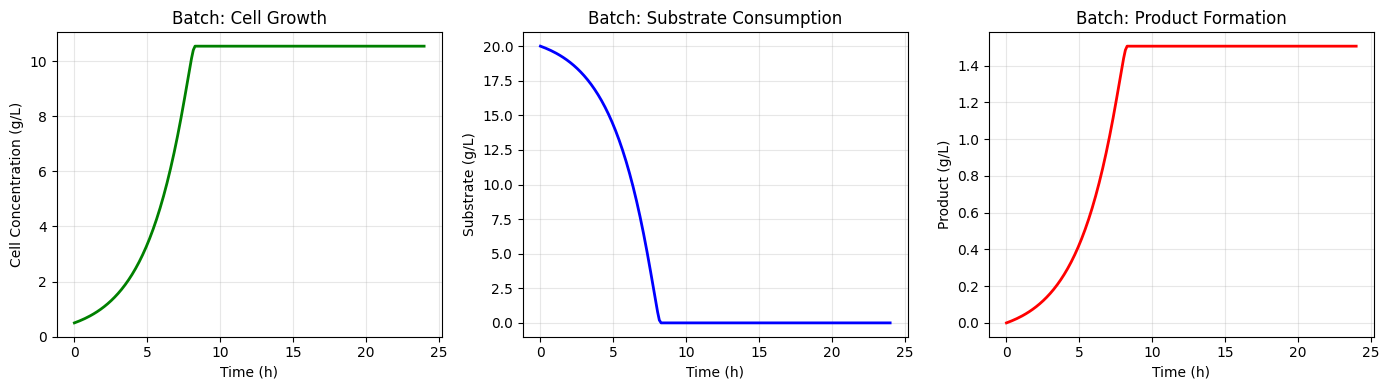

Final cell concentration: 10.54 g/L
Final product concentration: 1.506 g/L


In [5]:
# Fed-batch parameters
fb_params = FedBatchParams(
    V0=5.0,                    # 5 L initial volume
    Y_xs=0.5,
    kinetic_fn=monod_kinetics,
    kinetic_params={
        "mu_max": jnp.array(0.4),
        "K_s": jnp.array(0.5),
    },
    alpha=0.15,                # Product formation
)

fedbatch = FedBatchBioreactor(fb_params)

# Batch mode (no feeding)
outlet_batch, info_batch = fedbatch(
    X0=0.5,    # Initial cells
    S0=20.0,   # Initial substrate
    P0=0.0,    # No initial product
    t_final=24.0,
    feed_rate_fn=None,  # Batch mode
    n_steps=200,
)

# Plot batch profiles
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(info_batch['t'], info_batch['X'], 'g-', linewidth=2)
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Cell Concentration (g/L)')
axes[0].set_title('Batch: Cell Growth')
axes[0].grid(True, alpha=0.3)

axes[1].plot(info_batch['t'], info_batch['S'], 'b-', linewidth=2)
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Substrate (g/L)')
axes[1].set_title('Batch: Substrate Consumption')
axes[1].grid(True, alpha=0.3)

axes[2].plot(info_batch['t'], info_batch['P'], 'r-', linewidth=2)
axes[2].set_xlabel('Time (h)')
axes[2].set_ylabel('Product (g/L)')
axes[2].set_title('Batch: Product Formation')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final cell concentration: {float(info_batch['X_final']):.2f} g/L")
print(f"Final product concentration: {float(info_batch['P_final']):.3f} g/L")

### Exponential Feeding Strategy

With exponential feeding, we can maintain cells in exponential growth phase longer.

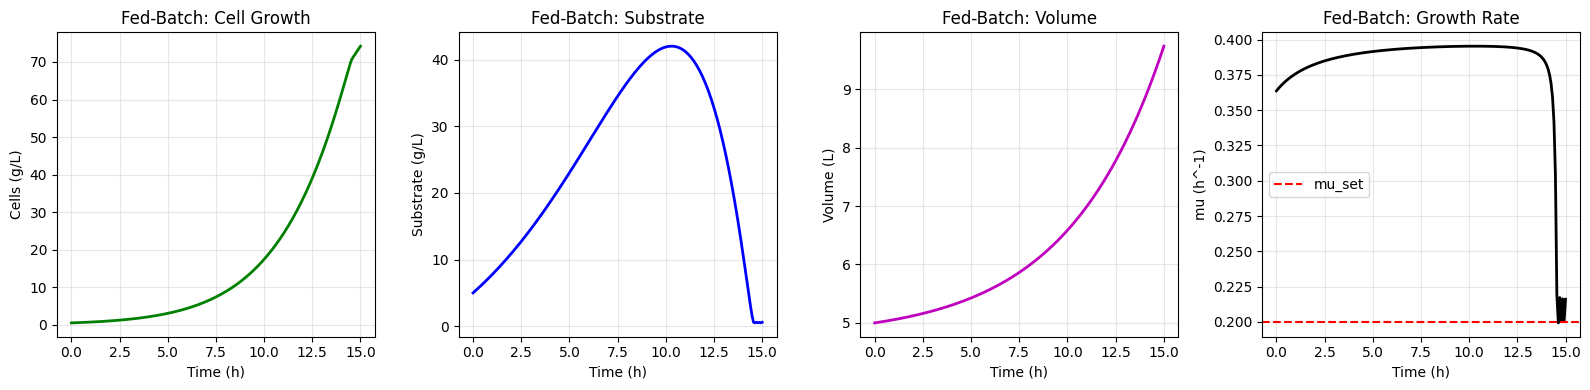

Final volume: 9.74 L
Final cell mass: 722.49 g


In [6]:
# Exponential feed rate
def exponential_feed(t):
    """Exponential feeding to maintain mu_set."""
    F0 = jnp.array(0.05)   # Initial feed rate L/h
    mu_set = jnp.array(0.2)  # Target growth rate
    return F0 * jnp.exp(mu_set * t)

outlet_fb, info_fb = fedbatch(
    X0=0.5,
    S0=5.0,    # Lower initial substrate
    P0=0.0,
    t_final=15.0,
    feed_rate_fn=exponential_feed,
    S_feed=300.0,  # Concentrated feed
    n_steps=200,
)

# Compare batch vs fed-batch
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(info_fb['t'], info_fb['X'], 'g-', linewidth=2)
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Cells (g/L)')
axes[0].set_title('Fed-Batch: Cell Growth')
axes[0].grid(True, alpha=0.3)

axes[1].plot(info_fb['t'], info_fb['S'], 'b-', linewidth=2)
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Substrate (g/L)')
axes[1].set_title('Fed-Batch: Substrate')
axes[1].grid(True, alpha=0.3)

axes[2].plot(info_fb['t'], info_fb['V'], 'm-', linewidth=2)
axes[2].set_xlabel('Time (h)')
axes[2].set_ylabel('Volume (L)')
axes[2].set_title('Fed-Batch: Volume')
axes[2].grid(True, alpha=0.3)

axes[3].plot(info_fb['t'], info_fb['mu'], 'k-', linewidth=2)
axes[3].axhline(y=0.2, color='r', linestyle='--', label='mu_set')
axes[3].set_xlabel('Time (h)')
axes[3].set_ylabel('mu (h^-1)')
axes[3].set_title('Fed-Batch: Growth Rate')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final volume: {float(info_fb['V_final']):.2f} L")
print(f"Final cell mass: {float(outlet_fb['F_cells']):.2f} g")

## 3. Summary

Key features of difflow_bio bioreactor models:

1. **Plug-in kinetics**: Use Monod, substrate inhibition, or custom kinetic functions
2. **Full differentiability**: Compute gradients for optimization
3. **Flexible operation modes**: Batch, fed-batch, or continuous
4. **Product formation**: Growth-associated (alpha) and non-growth-associated (beta) terms